4*2 이미지를 만드는 코드

C:\Users\minkyu\AppData\Local\Temp\ipykernel_36088\4007299058.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # 오른쪽에 여백을 두어 컬러바가 겹치지 않도록


../정리/Scientific Reports/2D/False_np5_nl10_biased_diamond_False_Mar08_18_52_18\False_np5_nl10_biased_diamond_False_Mar08_18_52_18.csv
Loaded False_np5_nl10_biased_diamond_False_Mar08_18_52_18.csv
max p-value: 0.0135798021174287, D_ks 0.4118508064516129 at epoch 288/300
angle = 10.723619330149743, MI = 0.1695725110269361, norm1 = 0.18088678091675045, norm2 = 0.48430325963844045
../정리/Scientific Reports/2D/False_np5_nl10_biased_diamond_False_Mar08_18_52_22\False_np5_nl10_biased_diamond_False_Mar08_18_52_22.csv
Loaded False_np5_nl10_biased_diamond_False_Mar08_18_52_22.csv
max p-value: 0.0917090229545913, D_ks 0.3459395161290323 at epoch 151/300
angle = 86.19024556798308, MI = 0.252968258735153, norm1 = 0.06358983438691422, norm2 = 0.6963279004316815


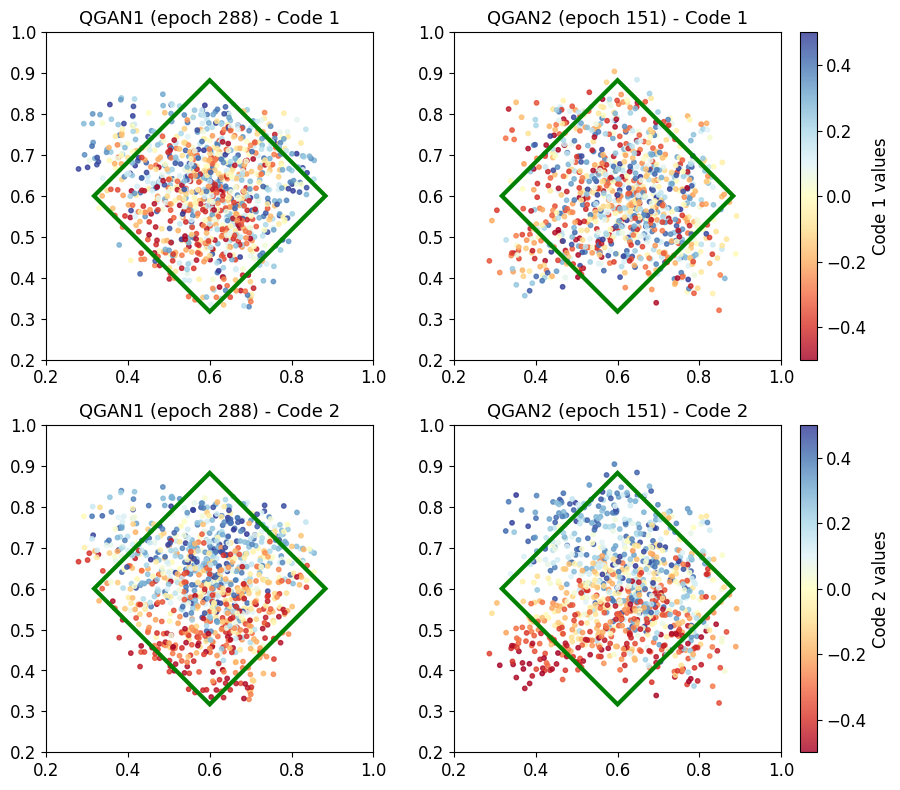

In [59]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

result_dir = "../정리/Scientific Reports/2D/"
experiment_names = [ 
    "False_np5_nl10_biased_diamond_False_Mar08_18_52_18", "False_np5_nl10_biased_diamond_False_Mar08_18_52_22",
    "True_np5_nl10_biased_diamond_True_Mar08_18_52_11", "True_np5_nl10_biased_diamond_True_Mar08_18_52_16",
]

def drawing_process(experiment_names, model_name, title):
    # True와 False에 대한 figure와 axes를 생성합니다.
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), gridspec_kw={'wspace': 0.1})
    plt.tight_layout(rect=[0, 0, 0.9, 1])  # 오른쪽에 여백을 두어 컬러바가 겹치지 않도록
    subtitle_fontsize = 13
    plt.rcParams['xtick.labelsize'] = subtitle_fontsize-1  # x축 눈금 글자 크기
    plt.rcParams['ytick.labelsize'] = subtitle_fontsize-1  # y축 눈금 글자 크기  

    for idx, experiment_name in enumerate(experiment_names):
        experiment_path = os.path.join(result_dir, experiment_name, f"{experiment_name}.csv")
        print(experiment_path)

        df = None
        if os.path.exists(experiment_path):
            # If the file exists, read it into a pandas DataFrame
            df = pd.read_csv(experiment_path)
            print(f"Loaded {experiment_name}.csv")

        max_p_value = df["p_value"].max()
        epoch_max_p_value = df[df["p_value"] == max_p_value]["epoch"].iloc[0]
        D_ks = df["D_ks"][epoch_max_p_value]
        angle = df["angle"][epoch_max_p_value]
        mi = df["MI"][epoch_max_p_value]
        x1 = df["Corr/code0-x"][epoch_max_p_value]
        y1 = df["Corr/code0-y"][epoch_max_p_value]
        norm1 = np.sqrt(x1**2 + y1**2)
        x2 = df["Corr/code1-x"][epoch_max_p_value]
        y2 = df["Corr/code1-y"][epoch_max_p_value]
        norm2 = np.sqrt(x2**2 + y2**2)
        print(f"max p-value: {max_p_value}, D_ks {D_ks} at epoch {epoch_max_p_value}/{len(df)}")
        print(f"angle = {angle}, MI = {mi}, norm1 = {norm1}, norm2 = {norm2}")

        # 데이터 파일 경로 설정
        outputs_path = os.path.join(result_dir, experiment_name, f"numpy/gen_outputs_epoch_{epoch_max_p_value}.txt")
        codes_path = os.path.join(result_dir, experiment_name, f"numpy/gen_codes_epoch_{epoch_max_p_value}.txt")

        # 데이터가 존재하는지 확인
        if not os.path.exists(outputs_path) or not os.path.exists(codes_path):
            print(f"Data files for epoch {epoch_max_p_value} not found in {outputs_path}.")
            continue  # 데이터가 없으면 다음 실험으로 넘어갑니다.

        # 데이터 로드
        outputs = np.loadtxt(outputs_path)
        codes = np.loadtxt(codes_path)

        # 첫 번째 코드와 두 번째 코드를 각각 사용하여 색상을 지정합니다.
        code1 = codes[:, 0]
        code2 = codes[:, 1]
        ax1 = axes[0][idx]
        ax2 = axes[1][idx]

        # 첫 번째 코드로 색상 지정하여 플롯 (RdYlBu cmap 및 alpha 값 적용)
        scatter1 = ax1.scatter(outputs[:, 0], outputs[:, 1], c=code1, cmap='RdYlBu', s=10, alpha=0.8)
        ax1.set_title(f'{model_name}{idx+1} (epoch {epoch_max_p_value}) - Code 1', fontsize=subtitle_fontsize)
        ax1.set_xlim(0.2, 1)
        ax1.set_ylim(0.2, 1)
        ax1.set_aspect('equal')

        # 중심 (0.6, 0.6), 팔 길이 0.2sqrt(2)인 다이아몬드 추가
        arm = 0.2 * np.sqrt(2)
        diamond = patches.Polygon([[0.6+arm, 0.6], [0.6, 0.6-arm], [0.6-arm, 0.6], [0.6, 0.6+arm]], closed=True, fill=False, edgecolor='green', linewidth=3)
        ax1.add_patch(diamond)

        # 두 번째 코드로 색상 지정하여 플롯 (RdYlBu cmap 및 alpha 값 적용)
        scatter2 = ax2.scatter(outputs[:, 0], outputs[:, 1], c=code2, cmap='RdYlBu', s=10, alpha=0.8)
        ax2.set_title(f'{model_name}{idx+1} (epoch {epoch_max_p_value}) - Code 2', fontsize=subtitle_fontsize)
        ax2.set_xlim(0.2, 1)
        ax2.set_ylim(0.2, 1)
        ax2.set_aspect('equal')
        
        # 중심 (0.6, 0.6), 팔 길이 0.2sqrt(2)인 다이아몬드 추가
        arm = 0.2 * np.sqrt(2)
        diamond = patches.Polygon([[0.6+arm, 0.6], [0.6, 0.6-arm], [0.6-arm, 0.6], [0.6, 0.6+arm]], closed=True, fill=False, edgecolor='green', linewidth=3)
        ax2.add_patch(diamond)

    # True 실험에 대해 오른쪽 열에만 컬러바 추가
    fig.subplots_adjust(left=0.05, right=0.85, top=0.95, bottom=0.05)
    cbar_true1 = fig.colorbar(scatter1, ax=axes[0][-1], location='right', fraction=0.05)
    cbar_true1.set_label('Code 1 values', fontsize=subtitle_fontsize-1)
    cbar_true2 = fig.colorbar(scatter2, ax=axes[1][-1], location='right', fraction=0.05)
    cbar_true2.set_label('Code 2 values', fontsize=subtitle_fontsize-1)
    # fig.suptitle(title)

    plt.show()

drawing_process(experiment_names[:2], "QGAN", "Generated by QGAN")

C:\Users\minkyu\AppData\Local\Temp\ipykernel_36088\4007299058.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # 오른쪽에 여백을 두어 컬러바가 겹치지 않도록


../정리/Scientific Reports/2D/True_np5_nl10_biased_diamond_True_Mar08_18_52_11\True_np5_nl10_biased_diamond_True_Mar08_18_52_11.csv
Loaded True_np5_nl10_biased_diamond_True_Mar08_18_52_11.csv
max p-value: 0.6663867513467163, D_ks 0.062391129032258 at epoch 56/300
angle = 87.32058199867555, MI = 2.0617387121723545, norm1 = 0.9718636544706825, norm2 = 0.9889775020571661
../정리/Scientific Reports/2D/True_np5_nl10_biased_diamond_True_Mar08_18_52_16\True_np5_nl10_biased_diamond_True_Mar08_18_52_16.csv
Loaded True_np5_nl10_biased_diamond_True_Mar08_18_52_16.csv
max p-value: 0.7027612721691088, D_ks 0.0591491935483871 at epoch 271/300
angle = 88.84936570669922, MI = 2.7518127868252416, norm1 = 1.0138734682475437, norm2 = 0.9501182742327837


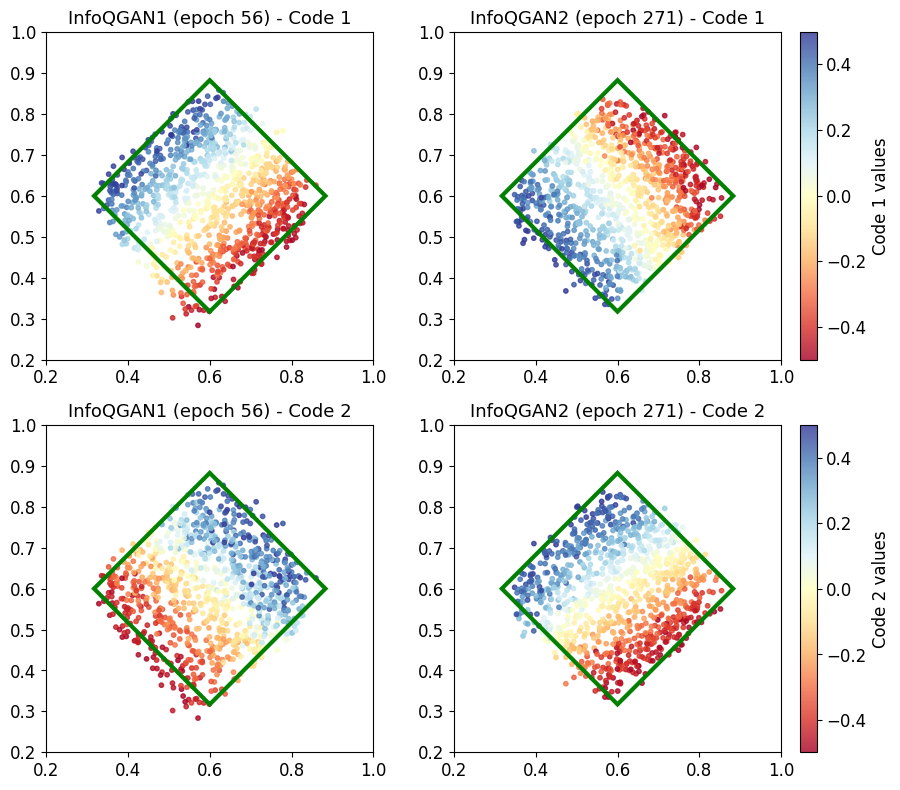

In [60]:
drawing_process(experiment_names[2:], "InfoQGAN", "Generated by InfoQGAN")